In [1]:
# Magics
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Resets to standard white background
import seaborn as sns
sns.set_theme()
sns.set_style('ticks')
sns.set_context('talk')
from ephys.decoder import *

# Load data

## Load spike counts

In [ ]:
subject = '007'
folder_parent = Path.home() / 'data' / subject

ephys_ids = [
    '007_2024-06-22_10-48-57',
    '007_2024-06-23_12-46-55',
    '007_2024-06-24_17-47-22',
    '007_2024-06-25_15-54-23',
    '007_2024-06-26_15-19-30',
    '007_2024-06-27_15-06-28',
    '007_2024-06-28_14-18-51',
    '007_2024-06-29_16-24-52',
    # '007_2024-07-06_11-16-25',  # Bad session
    # '007_2024-07-07_13-20-29',  # Bad session
    '007_2024-07-08_12-20-29',
    '007_2024-07-09_12-10-57',
    '007_2024-07-10_12-03-35',
    '007_2024-07-11_12-39-21',
    '007_2024-07-12_13-29-26'
]

# Load spike counts for all neurons of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Get spike counts
    if any(f.endswith('.npy') for f in os.listdir(folder_child)):
        print('Files exist in folder. Skipping')
        continue
    else:
        print('Files do not exist in folder. Proceeding')
        df_ttl, df_behavior, n_trials, df_spikes, cluster_info, x, height, labels, y, width, left, ts_edges, events_edges = \
            preprocess(ephys_ids[i])
        bins, all_psth = get_all_psth(cluster_info, df_spikes, df_ttl, n_trials, time_win=[-1, 3], bin_size=0.1)
    # Save bins and psth
    np.save(folder_child / 'bins.npy', bins)
    np.save(folder_child / 'all_psth.npy', all_psth)

## Load behavior

In [ ]:
# Load behavior of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    print(f'Parsing behavioral session {i + 1}/{len(ephys_ids)}: {filename[:-4]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Execute only if folder is empty
    if any(f.endswith('.csv') for f in os.listdir(folder_child)):
        print('File exist in folder. Skipping')
        continue
    else:
        print('File does not exist in folder. Proceeding')
        df_behavior = parse_v2(path_behavior)
        df_behavior.to_csv(folder_child / filename, index=False)


behavior = []
for i in range(len(ephys_ids)):
    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    folder_child = folder_parent / ephys_ids[i]
    df = pd.read_csv(folder_child / filename)
    behavior.append(df)

# # Get behavioral events
# stim_dur = df_behavior.StimDur.unique()[0]
# delay = df_behavior.Delay.unique()[0]
# go_cue = stim_dur + delay

In [61]:
def find_disengaged(df_behavior, threshold=0.5, min_trial=200, win_len=20, plot=False):
    """
    Find the first trial where the animal disengages from the task based on side accuracy.
    :param df_behavior: DataFrame with behavioral data
    :param threshold: threshold accuracy to consider the animal disengaged
    :param min_trial: minimum trial to start looking for disengagement
    :param win_len: window length to compute rolling average
    :return: first_trial (int)
    """

    x_total, y_total, x_0, y_0, x_1, y_1 = get_roll_avg(df_behavior, kind='side')

    # Convert indices to lists to ensure compatibility
    x_0, x_1, x_total = list(x_0), list(x_1), list(x_total)

    # Adjust minimum trial to account for the running window
    min_valid_trial = min_trial + win_len

    # Filter trials starting from min_valid_trial
    filtered_x_total = [(x, y) for x, y in zip(x_total, y_total) if x >= min_valid_trial]
    filtered_x_0 = [(x, y) for x, y in zip(x_0, y_0) if x >= min_valid_trial]
    filtered_x_1 = [(x, y) for x, y in zip(x_1, y_1) if x >= min_valid_trial]

    # Find first trial where y_total reaches threshold
    idx_total = next(((x, y) for x, y in filtered_x_total if y <= threshold), None)

    # Find first trial where y_0 or y_1 reaches threshold, mapped back to absolute trials
    idx_0 = next(((x_total[x_total.index(x)], y) for x, y in filtered_x_0 if y <= threshold), None) if filtered_x_0 else None
    idx_1 = next(((x_total[x_total.index(x)], y) for x, y in filtered_x_1 if y <= threshold), None) if filtered_x_1 else None

    # Get the earliest occurrence and corresponding y-value
    disengaged_trial, disengaged_y = min(filter(None, [idx_total, idx_0, idx_1]), default=(None, None))

    # Side accuracy plot
    if plot:
        plt.figure(constrained_layout=True)
        plt.plot(x_total, y_total, color='k')
        plt.plot(x_0, y_0, color='tab:blue')
        plt.plot(x_1, y_1, color='tab:orange')
        plt.axhline(0.25, color='tab:gray', ls=':')
        plt.axhline(0.5, color='tab:gray', ls='--')
        plt.axhline(0.75, color='tab:gray', ls=':')

        # Plot the red dot at the correct x (absolute trial number) and y=0.5
        if disengaged_trial is not None:
            plt.plot(disengaged_trial, threshold, 'ro')

        plt.xlabel('Trial')
        plt.ylabel('Side acc.')
        plt.title(df_behavior.Session.unique()[0])
        sns.despine()

    return disengaged_trial

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

In [63]:
disengaged = [find_disengaged(behavior[i], plot=False) for i in range(len(behavior))]

# Within Temporal Decoder (mean)

In [6]:
%%time
# Run mean within decoder across sessions
# results = mean_decoder(kind='within', save=True)

CPU times: total: 0 ns
Wall time: 0 ns


In [7]:
# Load mean within decoder results across sessions
with open(Path(folder_parent / 'results_mean_within_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 9513 trials')

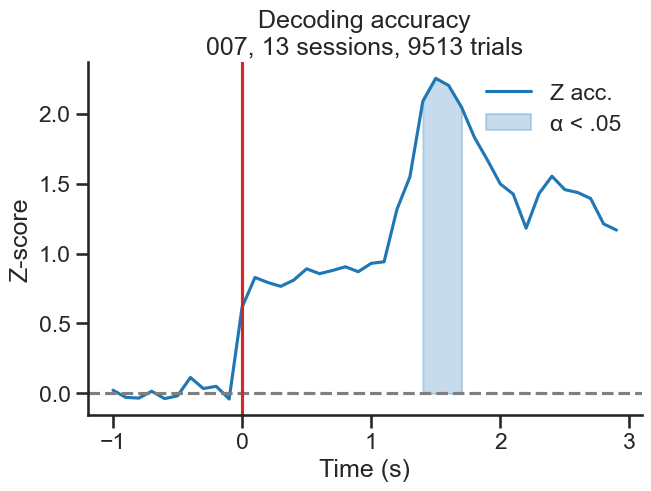

In [8]:
# Plot mean within decoder results across sessions
plot_mean_within_decoder(results, z_null=True)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f"{subject}, {n_sessions} sessions, {n_trials} trials")

# Cross Temporal Decoder (mean)

In [9]:
%%time
# Run mean cross decoder across sessions
# results = mean_decoder(kind='cross', save=True)

CPU times: total: 0 ns
Wall time: 0 ns


In [10]:
# Load mean cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_cross_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n 007, 13 sessions, 9513 trials')

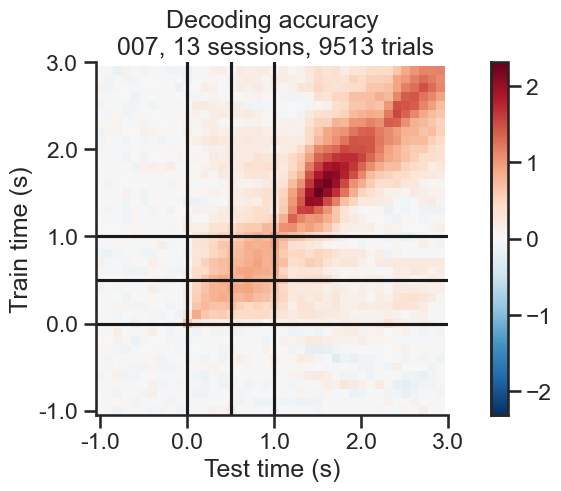

In [11]:
# Plot mean within decoder results across sessions
plot_mean_cross_decoder(results, z_null=True)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f" {subject}, {n_sessions} sessions, {n_trials} trials")

# Epoch Cross Temporal Decoder (mean)

In [ ]:
%%time
# Run mean epoch cross decoder across sessions
results_stim = mean_decoder(kind='epoch', epoch='stim', save=True)
results_delay = mean_decoder(kind='epoch', epoch='delay', save=True)
results_resp = mean_decoder(kind='epoch', epoch='resp', save=True)

In [15]:
# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim.pkl'), 'rb') as f:
    results_stim = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay.pkl'), 'rb') as f:
    results_delay = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 9513 trials')

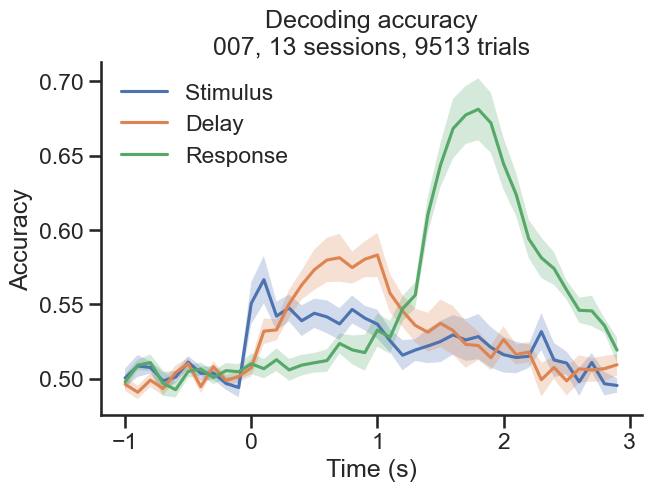

In [16]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['pred'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus code split by Outcome (blue trace in mean epoch cross temporal decoder)
2 approaches that should lead to the same mean accuracy but **different** null accuracy:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials). Mean null  accuracy should be the **same** for each split (flat at 0.5). This is **wrong**
2. Run the epoch cross decoder split function that performs the split when training the decoder. Mean null accuracy should be **different** for each split. This is **correct**

### 1. Run epoch cross decoder function for all trials and average across trial types

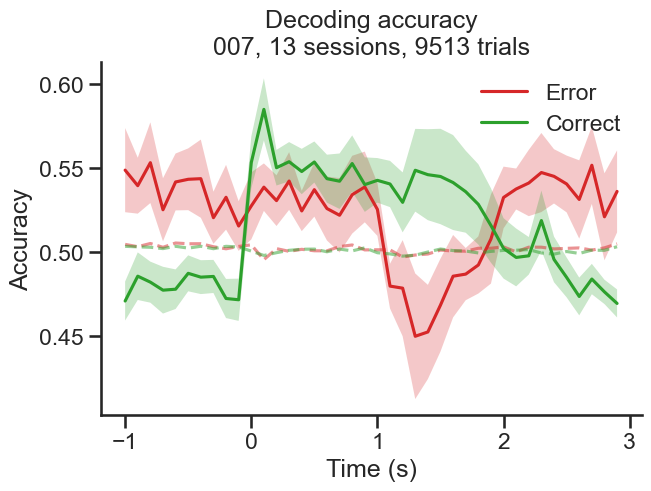

In [17]:
# Split stim decoder into correct vs error trials
# behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# hits = [list(np.where(behavior[i].Hit == True)[0]) for i in range(len(behavior))]
# errors = [list(np.where(behavior[i].Hit == False)[0]) for i in range(len(behavior))]
# misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]
# indexes = [[h, e] for h, e in zip(hits, errors)]

# Error trials
acc_mean_error = [np.nanmean(results_stim['acc'][i][indexes[i][0]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_error = np.array(acc_mean_error)
acc_sem_error = sem(acc_mean_error, axis=0, nan_policy='omit')
acc_mean_error = np.mean(acc_mean_error, axis=0)
acc_null_mean_error = [np.nanmean(results_stim['acc_null'][i][indexes[i][0]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_error = np.array(acc_null_mean_error)
acc_null_mean_error = np.nanmean(acc_null_mean_error, axis=0)

# Correct trials
acc_mean_correct = [np.nanmean(results_stim['acc'][i][indexes[i][1]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_correct = np.array(acc_mean_correct)
acc_sem_correct = sem(acc_mean_correct, axis=0, nan_policy='omit')
acc_mean_correct = np.nanmean(acc_mean_correct, axis=0)
acc_null_mean_correct = [np.nanmean(results_stim['acc_null'][i][indexes[i][1]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_correct = np.array(acc_null_mean_correct)
acc_null_mean_correct = np.nanmean(acc_null_mean_correct, axis=0)

plt.figure(constrained_layout=True)

# Error trials
plt.plot(results_stim['bins'][:-1], acc_mean_error, color='tab:red', label='Error')
plt.fill_between(results_stim['bins'][:-1], acc_mean_error - acc_sem_error,
                 acc_mean_error + acc_sem_error, color='tab:red', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_error, color='tab:red', ls='--', alpha=0.5)

# Correct trials
plt.plot(results_stim['bins'][:-1], acc_mean_correct, color='tab:green', label='Correct')
plt.fill_between(results_stim['bins'][:-1], acc_mean_correct - acc_sem_correct,
                 acc_mean_correct + acc_sem_correct, color='tab:green', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_correct, color='tab:green', ls='--', alpha=0.5)

n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

Note the same mean null accuracy for both splits. This is wrong.

### 2. Run epoch cross decoder split function that performs the split when training the decoder

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim = mean_decoder(kind='epoch_split', epoch='stim', split_by='Hit', save=True)

In [18]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_split_by_Hit.pkl'), 'rb') as f:
    results_stim = pickle.load(f)

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 9513 trials')

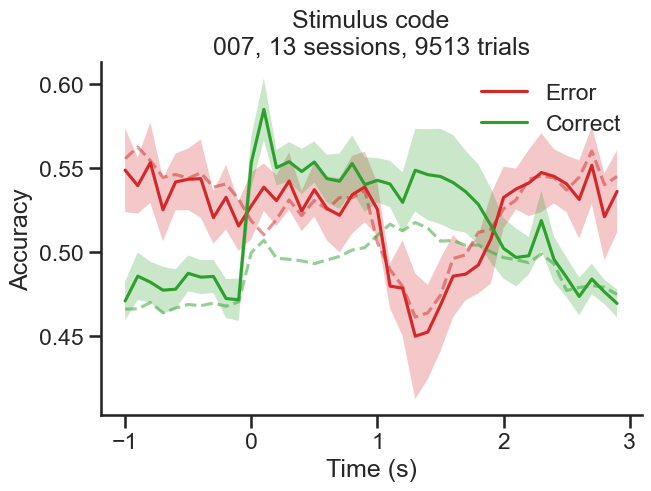

In [19]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim, z_null=True)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i][0].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

## Delay code split by Outcome (orange trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_delay = mean_decoder(kind='epoch_split', epoch='delay', split_by='Hit', save=True)

In [21]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_split_by_Hit.pkl'), 'rb') as f:
    results_delay = pickle.load(f)

Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 9513 trials')

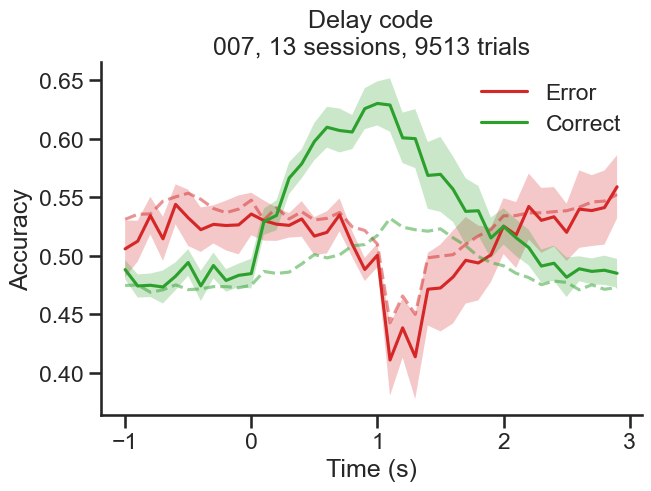

In [22]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay, z_null=True)
n_sessions = len(results_delay['acc'])
n_trials = np.sum([results_delay['acc'][i][0].shape[0] for i in range(len(results_delay['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Response code split by Outcome (green trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp = mean_decoder(kind='epoch_split', epoch='resp', split_by='Hit', save=True)

In [24]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_split_by_Hit.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Response code\n007, 13 sessions, 9513 trials')

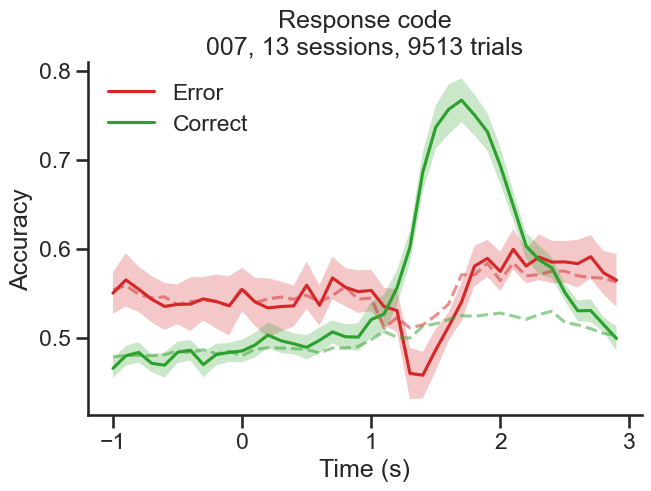

In [25]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp, z_null=True)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')